# Vehicle Engine Health Monitoring System (VEHMS)

## Predictive Maintenance Framework using Stacked Ensemble Deep Learning

This notebook implements a comprehensive predictive maintenance framework that analyzes vehicle engine sensor data and environmental conditions to classify engine health into four categories:
- **Good**: Engine operating normally
- **Minor**: Minor issues detected, routine maintenance recommended
- **Moderate**: Moderate issues detected, maintenance required soon
- **Critical**: Critical issues detected, immediate attention required

### Target Performance Metrics
- **AUC**: ~0.9702
- **RMSE**: ~0.3355
- **Accuracy**: ~0.9470
- **Precision**: ~0.9486

## Install Library

In [1]:
# Core Data Science Libraries
!pip install pandas numpy scipy

# Visualization Libraries
!pip install matplotlib seaborn plotly

# Machine Learning Libraries
!pip install scikit-learn xgboost

# Explainable AI Libraries
!pip install shap lime

!pip install tensorflow


print("\n" + "="*60)
print("All packages installed successfully!")
print("="*60)
print("\nYou can now proceed to the next cell to import libraries.")


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

All packages installed successfully!

You can now proceed to the next cell to import libraries.


## 1. Setup and Configuration

In [1]:
# Core imports
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Import all VEHMS modules
from vehms import (
    DataLoader, DataVisualizer, DataCleaner, DataPreprocessor,
    FeatureExtractor, BaseClassifierModule, StackedEnsemble,
    ExistingResearchStackedEnsemble, DynamicClassifierSelector,
    ModelEvaluator, PerformanceVisualizer, XAIExplainer, RANDOM_SEED
)

# Set random seed for reproducibility
np.random.seed(RANDOM_SEED)

print("="*60)
print("VEHMS - Vehicle Engine Health Monitoring System")
print("="*60)
print(f"Random Seed: {RANDOM_SEED}")
print("All modules loaded successfully!")

VEHMS - Vehicle Engine Health Monitoring System
Random Seed: 42
All modules loaded successfully!


## 2. Data Loading and Validation

In [2]:
# Load and validate dataset
loader = DataLoader()
df = loader.load_dataset('dataset/augmented_data_with_environment.csv')
loader.validate_columns(df)
loader.validate_data_types(df)
loader.display_summary(df)

[OK] Dataset loaded successfully from: dataset/augmented_data_with_environment.csv
  Shape: 10000 rows x 10 columns
[OK] All 10 required columns validated

[OK] Validating numeric columns...
  All 9 numeric columns contain valid float values

[OK] Validating Decision column categories...
  Valid categories found: ['Critical', 'Good', 'Minor', 'Moderate']

  Category Distribution:
    Good: 2500 samples (25.0%)
    Minor: 2500 samples (25.0%)
    Moderate: 2500 samples (25.0%)
    Critical: 2500 samples (25.0%)

DATASET SUMMARY

[STATS] Dataset Shape:
   Rows (samples): 10,000
   Columns (features): 10

[LIST] Column Data Types:
----------------------------------------
   Crankshaft      : float64
   Overheating     : float64
   Lubricant       : float64
   Misfires        : float64
   Piston          : float64
   Starter         : float64
   Temperature     : float64
   Humidity        : float64
   Altitude        : float64
   Decision        : object

[CHART] Numeric Column Statistics

## 3. Exploratory Data Analysis

FEATURE DISTRIBUTION PLOTS


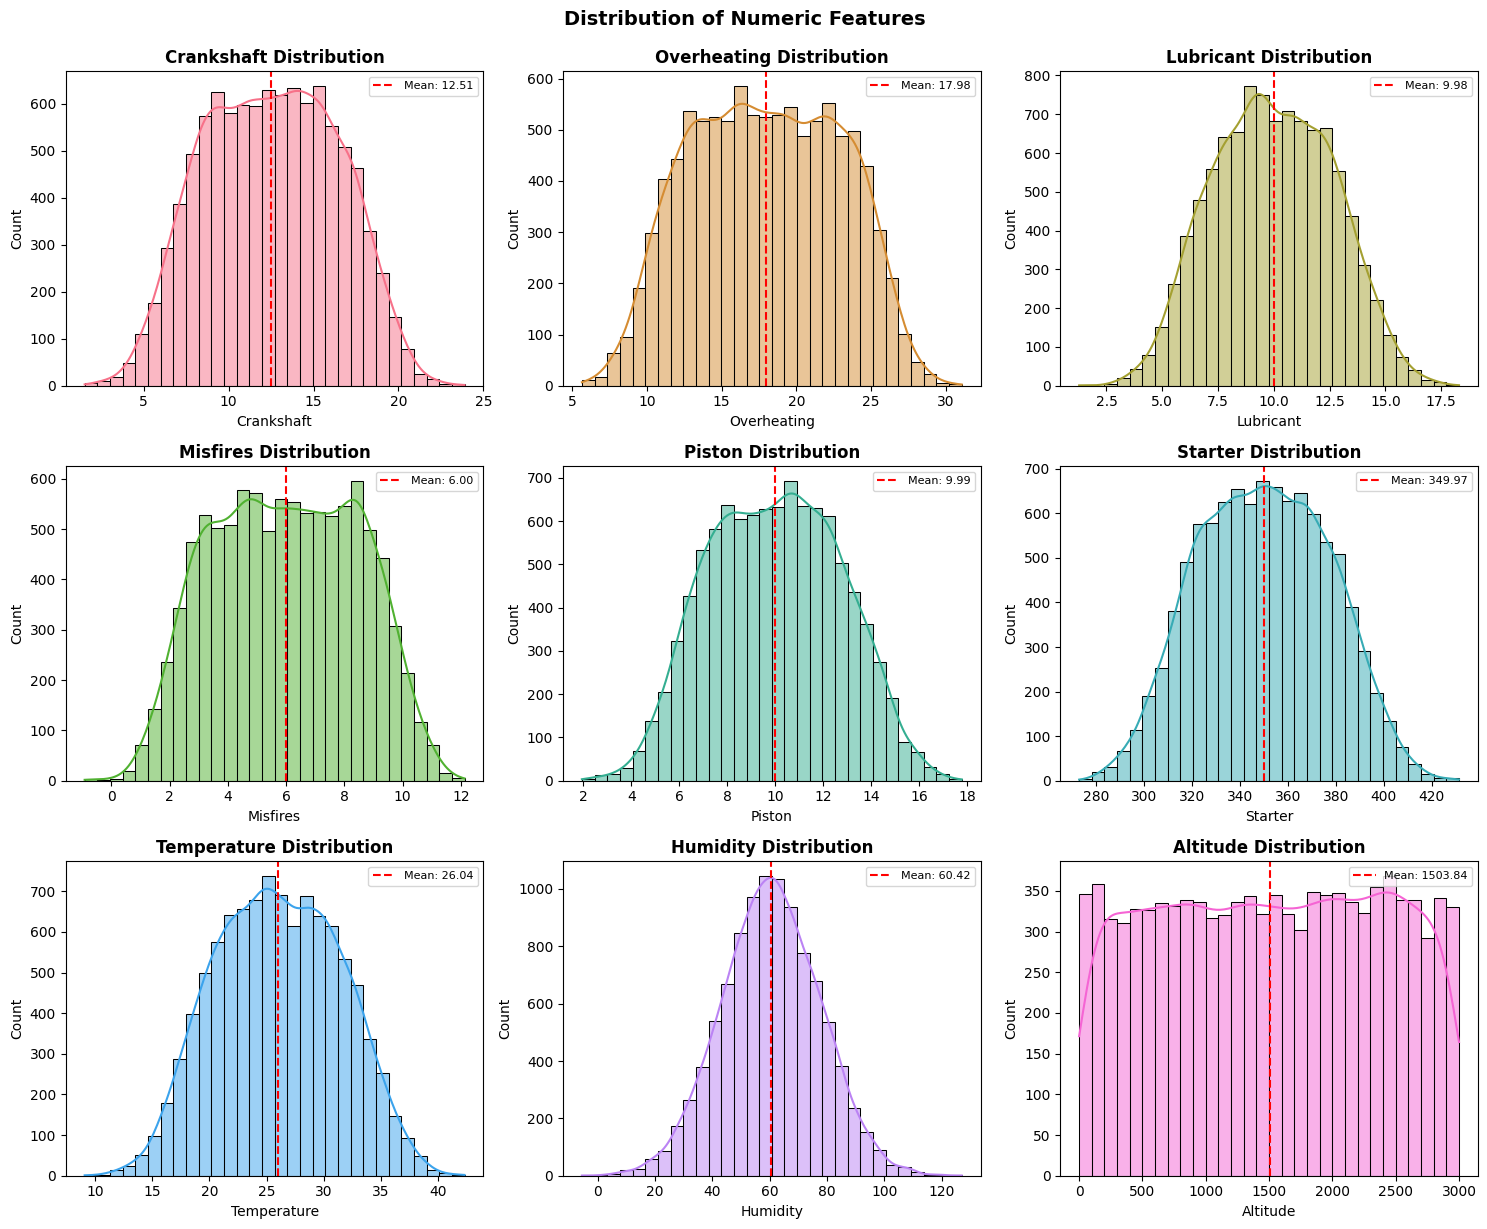

[OK] Distribution plots generated successfully
CORRELATION HEATMAP


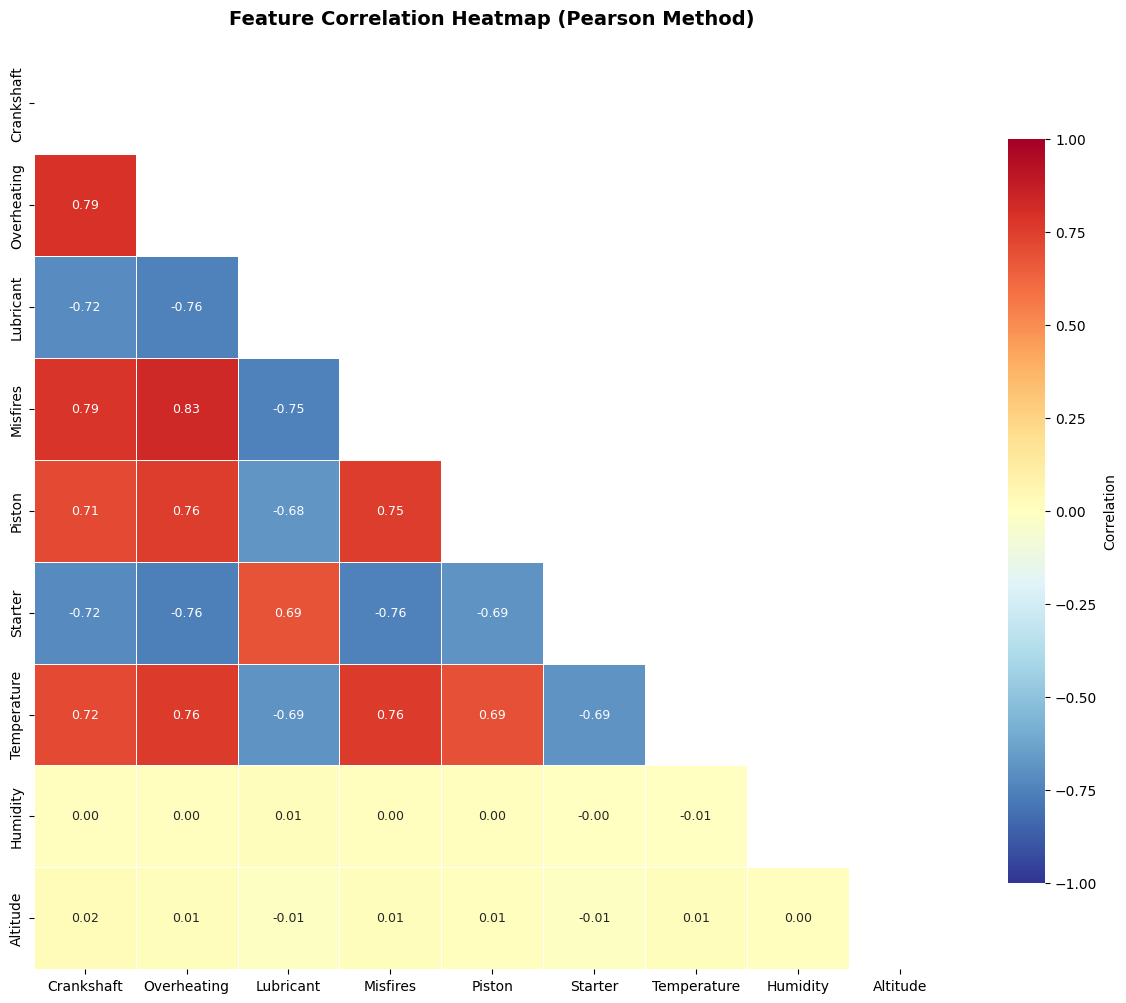


[OK] Correlation heatmap generated successfully
TARGET CLASS DISTRIBUTION


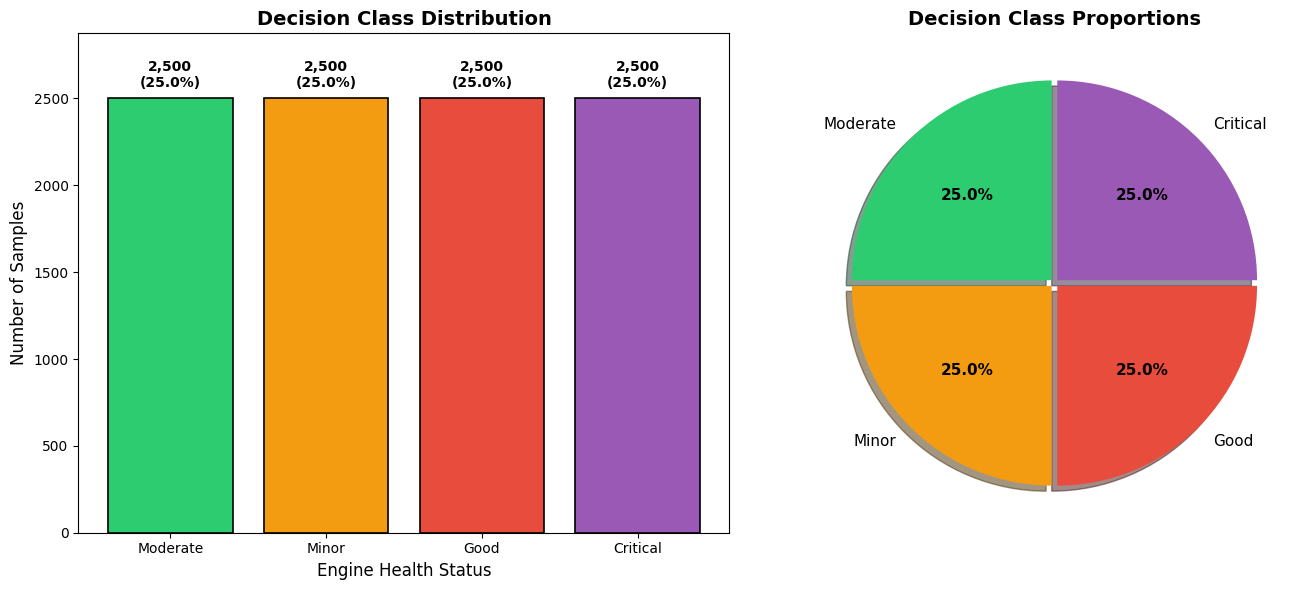


[STATS] Class Distribution Summary:
----------------------------------------
   Moderate  : 2,500 samples ( 25.0%)
   Minor     : 2,500 samples ( 25.0%)
   Good      : 2,500 samples ( 25.0%)
   Critical  : 2,500 samples ( 25.0%)

[OK] Class distribution plots generated successfully
BOX PLOTS FOR OUTLIER DETECTION


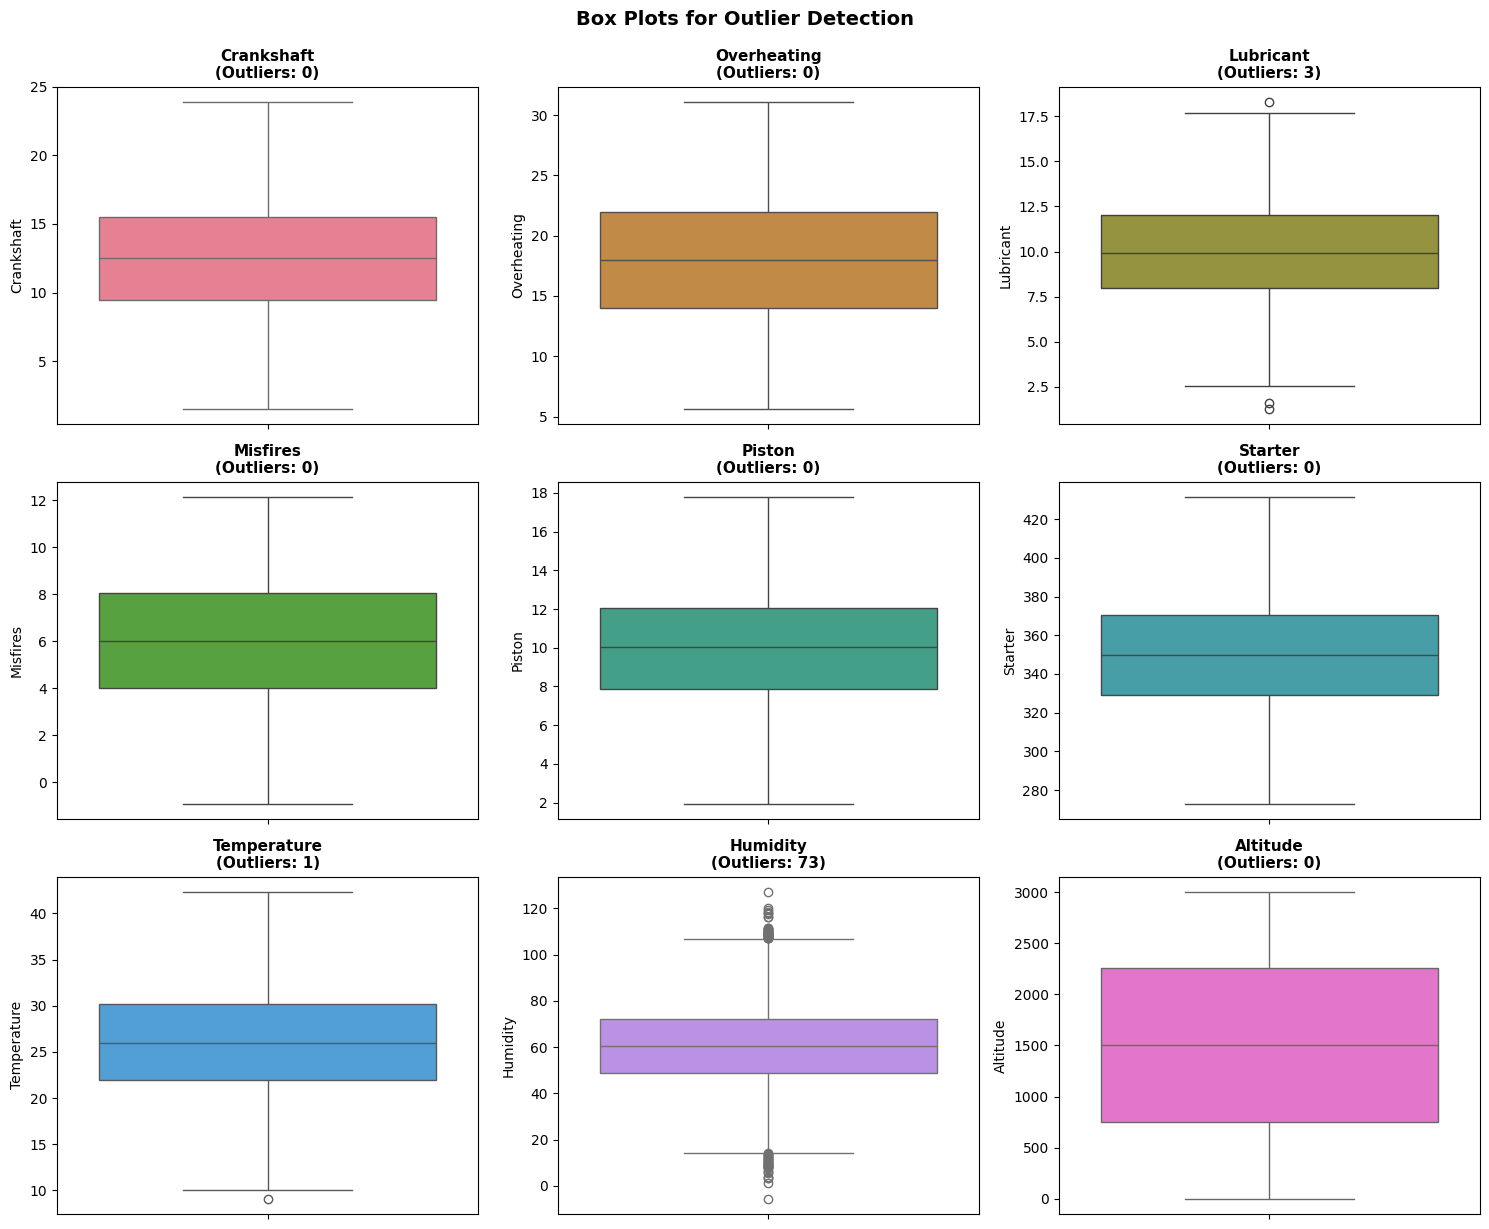


[STATS] Outlier Summary (IQR Method):
----------------------------------------
   Humidity       :    73 outliers ( 0.73%)
   Lubricant      :     3 outliers ( 0.03%)
   Temperature    :     1 outliers ( 0.01%)
   Crankshaft     :     0 outliers ( 0.00%)
   Overheating    :     0 outliers ( 0.00%)
   Misfires       :     0 outliers ( 0.00%)
   Piston         :     0 outliers ( 0.00%)
   Starter        :     0 outliers ( 0.00%)
   Altitude       :     0 outliers ( 0.00%)

[OK] Box plots generated successfully


In [3]:
# Create visualizer and generate EDA plots
visualizer = DataVisualizer()

# Distribution plots
visualizer.plot_distributions(df)

# Correlation heatmap
visualizer.plot_correlation_heatmap(df)

# Class distribution
visualizer.plot_class_distribution(df)

# Box plots for outlier detection
visualizer.plot_boxplots(df)

## 4. Data Cleaning

In [4]:
# Clean the dataset
cleaner = DataCleaner(outlier_method='iqr')
cleaner.cleaning_report['original_shape'] = df.shape

# Check and handle missing values
cleaner.check_missing_values(df)

# Check and remove duplicates
cleaner.check_duplicates(df)
df_cleaned = cleaner.remove_duplicates(df)

# Impute missing values if any
df_cleaned = cleaner.impute_missing(df_cleaned, strategy='median')

# Handle outliers
sensor_columns = ['Crankshaft', 'Overheating', 'Lubricant', 'Misfires', 
                  'Piston', 'Starter', 'Temperature', 'Humidity', 'Altitude']
df_cleaned = cleaner.handle_outliers(df_cleaned, columns=sensor_columns, action='clip')

cleaner.cleaning_report['final_shape'] = df_cleaned.shape
cleaner.get_cleaning_report()

MISSING VALUES ANALYSIS

[OK] No missing values detected in the dataset!

DUPLICATE ROWS ANALYSIS

[OK] No duplicate rows detected in the dataset!

DUPLICATE REMOVAL

[OK] No duplicates to remove!

MISSING VALUE IMPUTATION (Strategy: MEDIAN)

[OK] No imputation needed - no missing values found!

OUTLIER HANDLING (Method: IQR, Action: CLIP)

[OK] Lubricant: Clipped 3 outliers

[OK] Temperature: Clipped 1 outliers

[OK] Humidity: Clipped 73 outliers

----------------------------------------
Total outliers handled: 77

DATA CLEANING SUMMARY REPORT

[STATS] Dataset Shape:
   Original: 10,000 rows x 10 columns
   Final:    10,000 rows x 10 columns

[FILE] Duplicates Removed: 0

[OK] DATA CLEANING COMPLETE


{'missing_values': {'Crankshaft': {'count': 0, 'percentage': 0.0},
  'Overheating': {'count': 0, 'percentage': 0.0},
  'Lubricant': {'count': 0, 'percentage': 0.0},
  'Misfires': {'count': 0, 'percentage': 0.0},
  'Piston': {'count': 0, 'percentage': 0.0},
  'Starter': {'count': 0, 'percentage': 0.0},
  'Temperature': {'count': 0, 'percentage': 0.0},
  'Humidity': {'count': 0, 'percentage': 0.0},
  'Altitude': {'count': 0, 'percentage': 0.0},
  'Decision': {'count': 0, 'percentage': 0.0}},
 'duplicates_removed': 0,
 'values_imputed': {},
 'outliers_handled': {'Lubricant': {'count': 3,
   'lower_bound': 1.9007588991385393,
   'upper_bound': 18.090939157019747,
   'action': 'clip'},
  'Temperature': {'count': 1,
   'lower_bound': 9.570101592469785,
   'upper_bound': 42.51128991622301,
   'action': 'clip'},
  'Humidity': {'count': 73,
   'lower_bound': 14.303112311405421,
   'upper_bound': 106.67255421090647,
   'action': 'clip'}},
 'original_shape': (10000, 10),
 'final_shape': (10000, 1

## 5. Data Preprocessing

In [5]:
# Preprocess data for model training
preprocessor = DataPreprocessor(test_size=0.2, random_state=RANDOM_SEED)

# Separate features and target
X, y = preprocessor.separate_features_target(df_cleaned, target='Decision')
feature_names = preprocessor.feature_names

# Scale features
X_scaled = preprocessor.fit_transform_features(X)

# Encode target
y_encoded = preprocessor.encode_target(y)
label_encoder = preprocessor.label_encoder

# Split into train/test sets
X_train, X_test, y_train, y_test = preprocessor.train_test_split(X_scaled, y_encoded)

print(f"\nPreprocessing complete!")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

FEATURE-TARGET SEPARATION

[OK] Features (X): 9 columns
   Columns: Crankshaft, Overheating, Lubricant, Misfires, Piston, Starter, Temperature, Humidity, Altitude

[OK] Target (y): 'Decision' column
   Unique values: ['Moderate', 'Minor', 'Good', 'Critical']

FEATURE SCALING (StandardScaler)

[OK] StandardScaler fitted and applied to 9 features

[OK] All features now have mean ~ 0 and std ~ 1

TARGET ENCODING (LabelEncoder)

[OK] LabelEncoder fitted and applied to target variable

   Label Encoding Mapping:
----------------------------------------
   Critical   -> 0  (2,500 samples, 25.0%)
   Good       -> 1  (2,500 samples, 25.0%)
   Minor      -> 2  (2,500 samples, 25.0%)
   Moderate   -> 3  (2,500 samples, 25.0%)

TRAIN-TEST SPLIT (Stratified Sampling)

[OK] Data split with stratified sampling
   Random state: 42
   Test size: 20%

   Training Set:
   - X_train shape: (8000, 9)
   - y_train shape: (8000,)

   Testing Set:
   - X_test shape: (2000, 9)
   - y_test shape: (2000,)

   C

## 6. Feature Extraction and Analysis

FEATURE IMPORTANCE CALCULATION

Method: Random Forest
Training samples: 8,000
Features: 9

[...] Training RandomForestClassifier for importance calculation...

[OK] Feature importance calculated successfully!

   Model Training Accuracy: 1.0000

FEATURE IMPORTANCE RANKING

[STATS] Ranked Feature Importance Table:
----------------------------------------------------------------------
Rank   Feature           Importance   Percentage   Cumulative
----------------------------------------------------------------------
1      Misfires            0.294145       29.41%       29.41%
2      Overheating         0.279246       27.92%       57.33%
3      Crankshaft          0.142309       14.23%       71.56%
4      Temperature         0.080699        8.07%       79.63%
5      Lubricant           0.065612        6.56%       86.19%
6      Piston              0.062473        6.25%       92.44%
7      Starter             0.058578        5.86%       98.30%
8      Humidity            0.008578        0.86

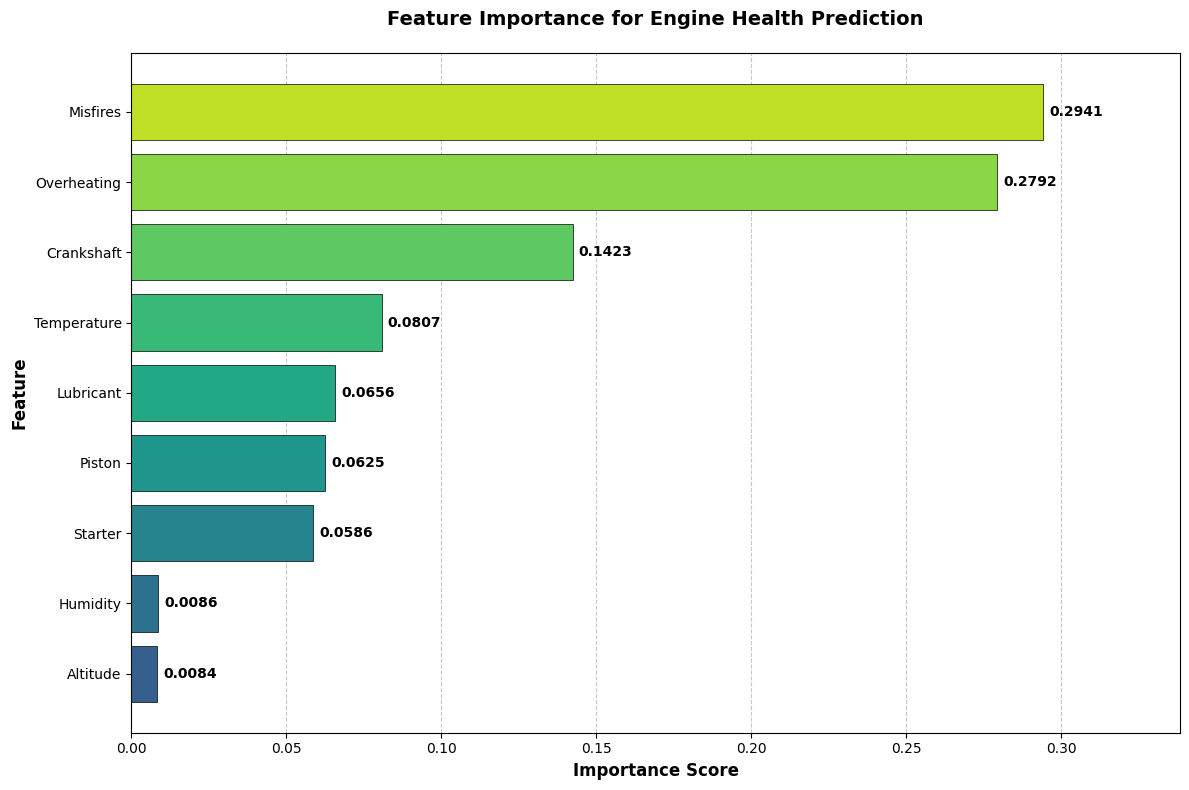


[OK] Feature importance visualization generated successfully!

TOP 5 CONTRIBUTING FEATURES

[TROPHY] Top 5 Features for Engine Health Prediction:
--------------------------------------------------
   1. Misfires        (Importance: 0.2941, 29.41%)
   2. Overheating     (Importance: 0.2792, 27.92%)
   3. Crankshaft      (Importance: 0.1423, 14.23%)
   4. Temperature     (Importance: 0.0807, 8.07%)
   5. Lubricant       (Importance: 0.0656, 6.56%)
--------------------------------------------------

   Combined contribution: 86.19% of total importance

[OK] Top 5 features identified successfully!


In [6]:
# Calculate and visualize feature importance
feature_extractor = FeatureExtractor()

# Calculate importance scores
importance_df = feature_extractor.calculate_importance(
    X=X_train, y=y_train, feature_names=feature_names, random_state=RANDOM_SEED
)

# Rank features
ranked_features = feature_extractor.rank_features()

# Visualize importance
feature_extractor.plot_importance()

# Get top features
top_5_features = feature_extractor.get_top_features(n=5)

## 7. Base Classifier Training

In [7]:
# Train all base classifiers
base_classifier_module = BaseClassifierModule(random_state=RANDOM_SEED)
classifier_results = base_classifier_module.train_all(X_train, y_train, X_test, y_test)

# Display results
print("\n" + "="*60)
print("BASE CLASSIFIER COMPARISON")
print("="*60)
print(classifier_results.to_string(index=False))

BASE CLASSIFIER MODULE INITIALIZED

Random State: 42

Available Classifiers: 10
--------------------------------------------------
   1. LR
   2. KNN
   3. LDA
   4. GNB
   5. SVM
   6. DT
   7. RF
   8. AdaBoost
   9. GB
  10. XGBoost
--------------------------------------------------

TRAINING ALL BASE CLASSIFIERS

Training samples: 8,000
Features: 9
Testing samples: 2,000

[...] Training LR classifier...
[OK] LR trained successfully!
   Training Time: 0.03 seconds
   Training Accuracy: 0.9701 (97.01%)
   Testing Accuracy:  0.9670 (96.70%)

[...] Training KNN classifier...
[OK] KNN trained successfully!
   Training Time: 0.00 seconds
   Training Accuracy: 0.9722 (97.22%)
   Testing Accuracy:  0.9625 (96.25%)

[...] Training LDA classifier...
[OK] LDA trained successfully!
   Training Time: 0.00 seconds
   Training Accuracy: 0.9692 (96.92%)
   Testing Accuracy:  0.9660 (96.60%)

[...] Training GNB classifier...
[OK] GNB trained successfully!
   Training Time: 0.00 seconds
   Training 

## 8. Stacked Ensemble Models (Proposed)

In [8]:
# Create and train proposed stacked ensemble models
stacked_ensemble = StackedEnsemble(cv=5, random_state=RANDOM_SEED)

# Stacked Model 1: KNN + SVM + RF + AdaBoost + XGBoost
model_1 = stacked_ensemble.create_stacked_model_1()
stacked_ensemble.train_stacked_model('Stacked Model 1', model_1, X_train, y_train)

# Stacked Model 2: RF + XGBoost + AdaBoost
model_2 = stacked_ensemble.create_stacked_model_2()
stacked_ensemble.train_stacked_model('Stacked Model 2', model_2, X_train, y_train)

# Stacked Model 3: KNN + SVM + RF
model_3 = stacked_ensemble.create_stacked_model_3()
stacked_ensemble.train_stacked_model('Stacked Model 3', model_3, X_train, y_train)

# Display architecture
stacked_ensemble.display_architecture('Stacked Model 1')


[...] Training Stacked Model 1...
   Base estimators: ['knn', 'svm', 'rf', 'ada', 'xgb']
   Meta-learner: LogisticRegression
   Cross-validation folds: 5

[OK] Stacked Model 1 trained successfully!
   Training time: 3.89 seconds
   Training accuracy: 0.9860 (98.60%)

[...] Training Stacked Model 2...
   Base estimators: ['rf', 'xgb', 'ada']
   Meta-learner: LogisticRegression
   Cross-validation folds: 5

[OK] Stacked Model 2 trained successfully!
   Training time: 2.37 seconds
   Training accuracy: 1.0000 (100.00%)

[...] Training Stacked Model 3...
   Base estimators: ['knn', 'svm', 'rf']
   Meta-learner: LogisticRegression
   Cross-validation folds: 5

[OK] Stacked Model 3 trained successfully!
   Training time: 2.17 seconds
   Training accuracy: 0.9886 (98.86%)

ARCHITECTURE: Stacked Model 1

                    +----------------------------+
                    |    Input Features (9)     |
                    +----------------------------+
                                 |
    

## 9. Existing Research Stacked Ensemble Models

In [9]:
# Create and train existing research stacked ensemble models
er_stacked_ensemble = ExistingResearchStackedEnsemble(cv=5, random_state=RANDOM_SEED)

# ER-Stacked Model 1: RF + SVM + GB + DT + KNN
er_model_1 = er_stacked_ensemble.create_er_stacked_model_1()
er_stacked_ensemble.train_stacked_model('ER-Stacked Model 1', er_model_1, X_train, y_train)

# ER-Stacked Model 2: LR + SVM + LDA + GB + AdaBoost
er_model_2 = er_stacked_ensemble.create_er_stacked_model_2()
er_stacked_ensemble.train_stacked_model('ER-Stacked Model 2', er_model_2, X_train, y_train)

# ER-Stacked Model 3: All 9 classifiers
er_model_3 = er_stacked_ensemble.create_er_stacked_model_3()
er_stacked_ensemble.train_stacked_model('ER-Stacked Model 3', er_model_3, X_train, y_train)


[...] Training ER-Stacked Model 1...
   Base estimators: ['rf', 'svm', 'gb', 'dt', 'knn']
   Meta-learner: LogisticRegression
   Cross-validation folds: 5

[OK] ER-Stacked Model 1 trained successfully!
   Training time: 8.94 seconds
   Training accuracy: 0.9885 (98.85%)

[...] Training ER-Stacked Model 2...
   Base estimators: ['lr', 'svm', 'lda', 'gb', 'ada']
   Meta-learner: LogisticRegression
   Cross-validation folds: 5

[OK] ER-Stacked Model 2 trained successfully!
   Training time: 8.93 seconds
   Training accuracy: 0.9722 (97.22%)

[...] Training ER-Stacked Model 3...
   Base estimators: ['lr', 'knn', 'svm', 'lda', 'gb', 'ada', 'dt', 'rf', 'gnb']
   Meta-learner: LogisticRegression
   Cross-validation folds: 5

[OK] ER-Stacked Model 3 trained successfully!
   Training time: 9.61 seconds
   Training accuracy: 0.9819 (98.19%)


,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('lr', ...), ('knn', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegre...ndom_state=42)
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",-1
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0

## 10. Dynamic Classifier Selection

[...] Fitting all classifiers...
   LR: 0.9670
   KNN: 0.9625
   LDA: 0.9660
   GNB: 0.9670
   SVM: 0.9660
   DT: 0.8990
   RF: 0.9540
   AdaBoost: 0.8885
   GB: 0.9555
   XGBoost: 0.9590

[CHART] Individual Classifier Performance (Ranked):
--------------------------------------------------
    1. LR         0.9670 |************************************************
    2. GNB        0.9670 |************************************************
    3. LDA        0.9660 |************************************************
    4. SVM        0.9660 |************************************************
    5. KNN        0.9625 |************************************************
    6. XGBoost    0.9590 |***********************************************
    7. GB         0.9555 |***********************************************
    8. RF         0.9540 |***********************************************
    9. DT         0.8990 |********************************************
   10. AdaBoost   0.8885 |**************

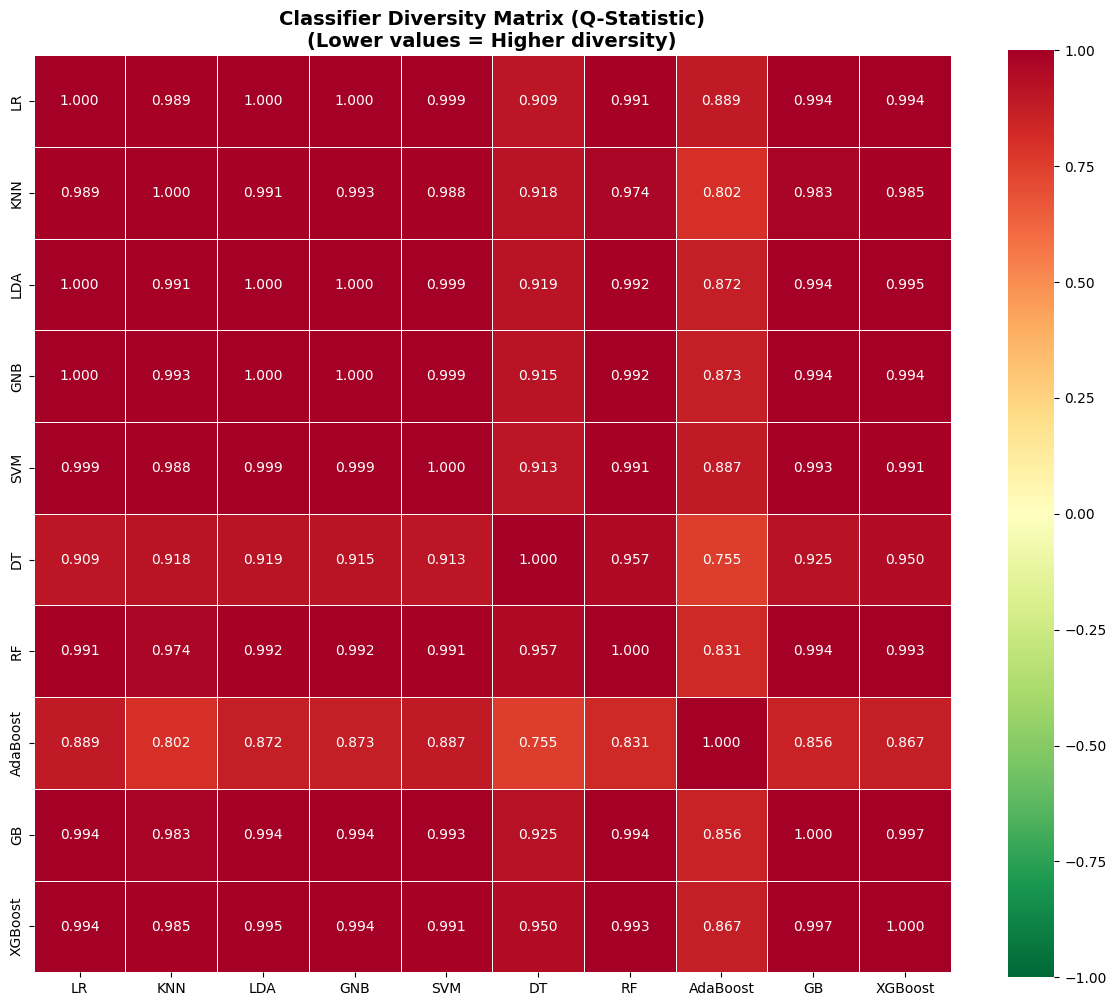

DS-Stack Performance: LR, GNB, LDA, SVM, KNN
DS-Stack Diversity: LR, AdaBoost, DT, KNN, RF
DS-Stack Combined: LR, KNN, AdaBoost, RF, GNB


In [10]:
# Dynamic classifier selection
selector = DynamicClassifierSelector(cv=5, random_state=RANDOM_SEED)

# Fit all classifiers
accuracies = selector.fit_all_classifiers(X_train, y_train, X_test, y_test)

# Calculate diversity matrix
diversity_matrix = selector.calculate_diversity_matrix(y_test)
selector.plot_diversity_heatmap()

# Run selection methods
perf_selected = selector.select_by_performance(top_k=5)
div_selected = selector.select_by_diversity(y_test, top_k=5)
combined_selected = selector.select_combined(y_test, top_k=5, performance_weight=0.6)

# Create and train dynamic stacks
ds_stacked_models = {}
for method, selected in [('Performance', perf_selected), ('Diversity', div_selected), ('Combined', combined_selected)]:
    stack = selector.create_dynamic_stack(selected)
    stack.fit(X_train, y_train)
    ds_stacked_models[f'DS-Stack {method}'] = {'model': stack, 'classifiers': selected}
    print(f"DS-Stack {method}: {', '.join(selected)}")

## 11. Model Evaluation

In [12]:
# Evaluate all models
evaluator = ModelEvaluator()

# Prepare models for evaluation
base_models = {
    'KNN': base_classifier_module.get_classifier('KNN'),
    'SVM': base_classifier_module.get_classifier('SVM'),
    'Random Forest': base_classifier_module.get_classifier('RF'),
    'AdaBoost': base_classifier_module.get_classifier('AdaBoost'),
    'XGBoost': base_classifier_module.get_classifier('XGBoost')
}

stacked_models = stacked_ensemble.get_all_models()
er_stacked_models = er_stacked_ensemble.get_all_models()

# Evaluate base classifiers
for name, model in base_models.items():
    evaluator.evaluate_model(model, X_test, y_test, model_name=name)

# Evaluate proposed stacked models
for name, model in stacked_models.items():
    evaluator.evaluate_model(model, X_test, y_test, model_name=name)

# Evaluate existing research stacked models
for name, model in er_stacked_models.items():
    evaluator.evaluate_model(model, X_test, y_test, model_name=name)

# Evaluate dynamic selection stacked models
for name, model_info in ds_stacked_models.items():
    evaluator.evaluate_model(model_info['model'], X_test, y_test, model_name=name)

# Generate comparison table
comparison_df = evaluator.compare_models()
print("\n" + "="*80)
print("MODEL COMPARISON TABLE")
print("="*80)
print(comparison_df.to_string(index=False))


MODEL COMPARISON TABLE
               Model     RMSE     RMSD    MAE  Accuracy  Precision      AUC
  ER-Stacked Model 2 0.366742 0.366742 0.0595    0.9655   0.965447 0.998431
   DS-Stack Combined 0.341321 0.341321 0.0535    0.9675   0.967453 0.998394
DS-Stack Performance 0.345688 0.345688 0.0535    0.9685   0.968477 0.998339
                 SVM 0.343511 0.343511 0.0550    0.9660   0.965975 0.998312
  DS-Stack Diversity 0.354260 0.354260 0.0565    0.9665   0.966445 0.998282
  ER-Stacked Model 3 0.361248 0.361248 0.0585    0.9655   0.965448 0.998268
     Stacked Model 3 0.368103 0.368103 0.0605    0.9645   0.964462 0.998075
     Stacked Model 1 0.361939 0.361939 0.0590    0.9650   0.964965 0.998067
  ER-Stacked Model 1 0.386005 0.386005 0.0650    0.9630   0.962954 0.998028
             XGBoost 0.420714 0.420714 0.0750    0.9590   0.958948 0.997353
     Stacked Model 2 0.421900 0.421900 0.0760    0.9580   0.957948 0.997287
       Random Forest 0.449444 0.449444 0.0850    0.9540   0.9539

## 12. Performance Visualization

MODEL PERFORMANCE COMPARISON CHARTS


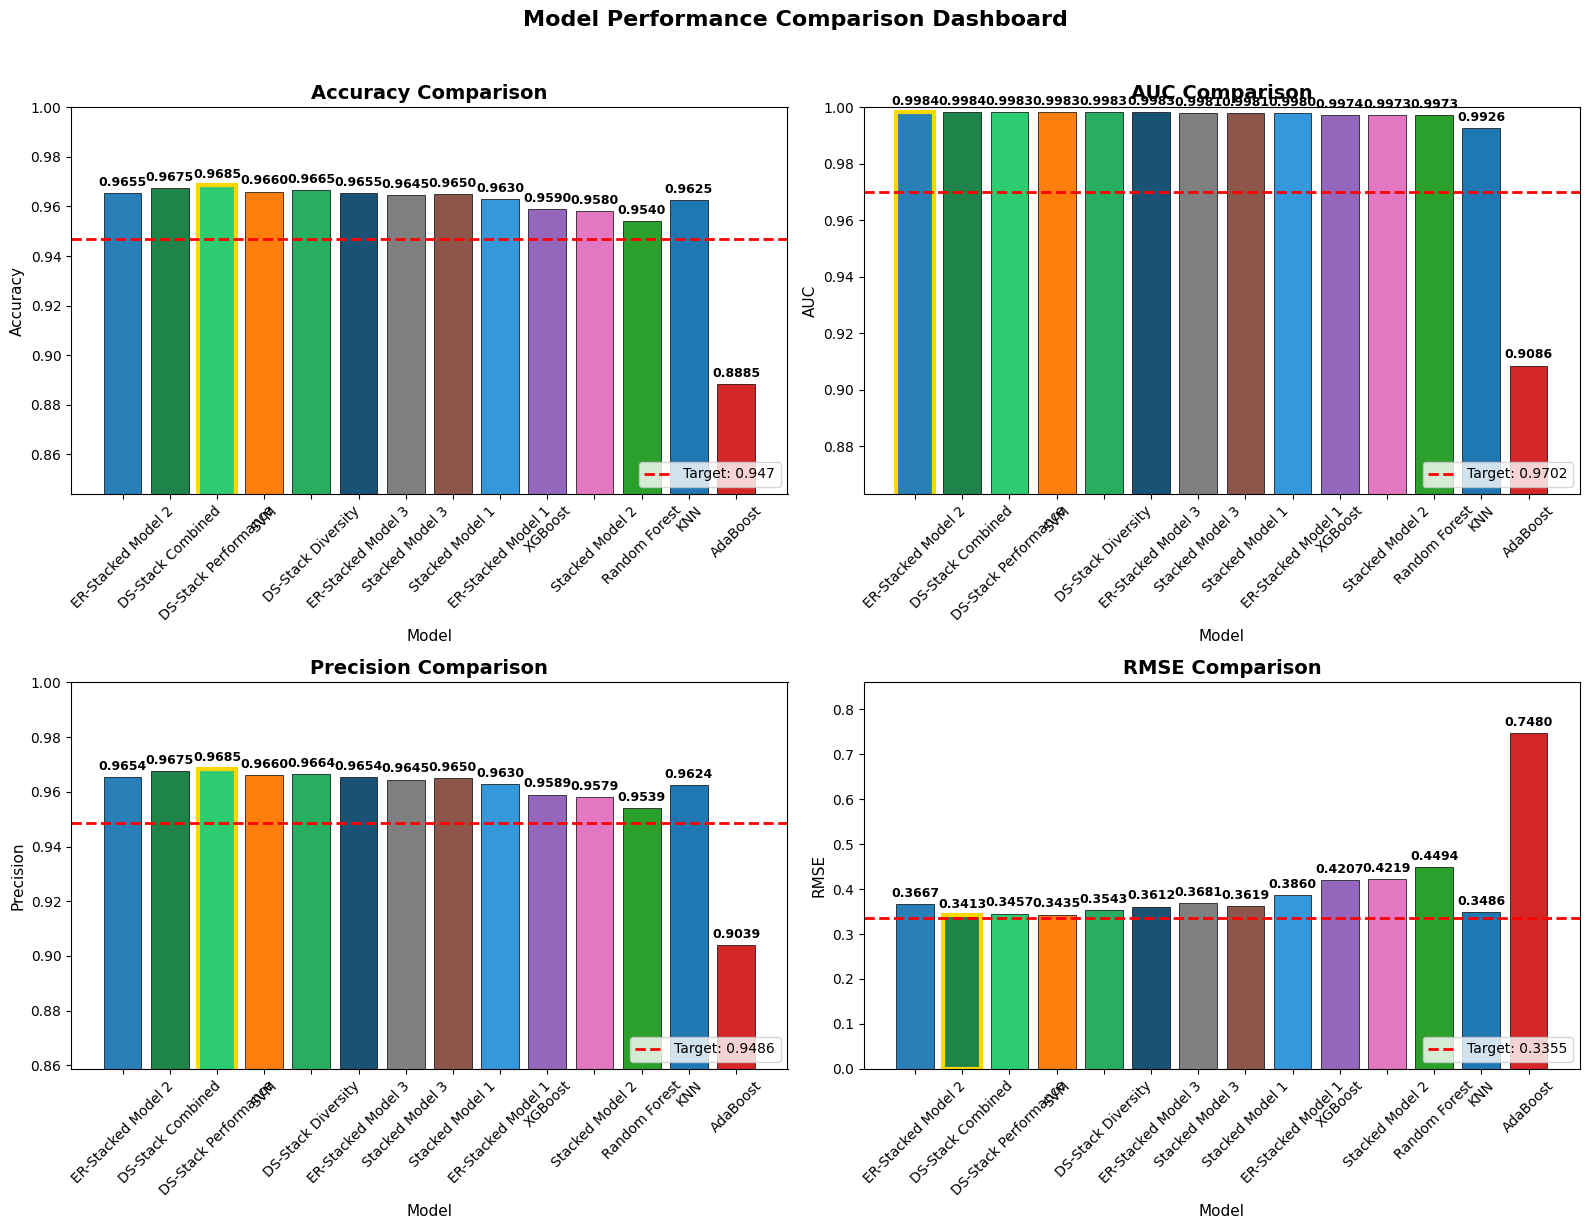


[OK] Model comparison charts generated successfully

ROC CURVES - ALL MODELS


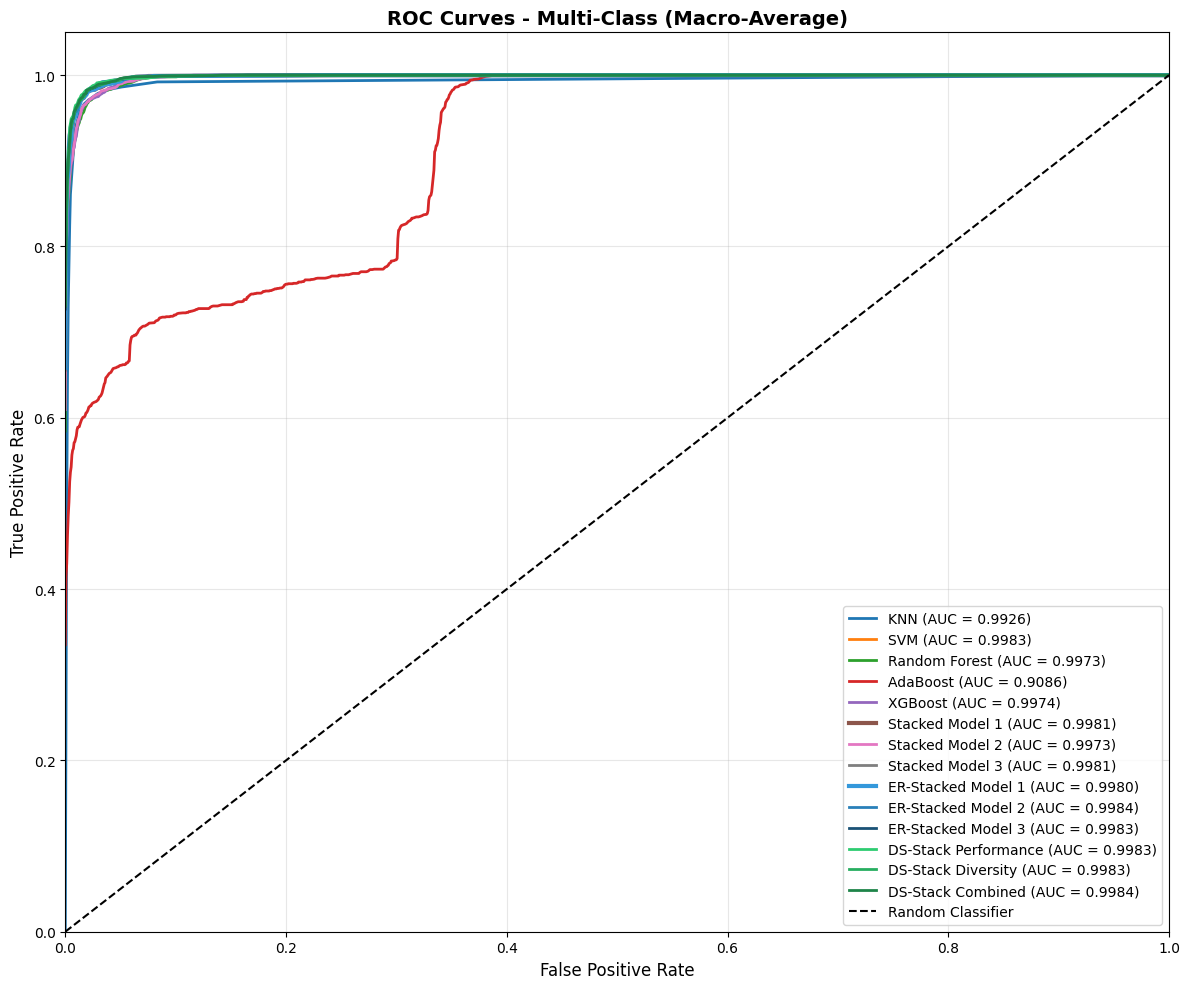


[OK] ROC curves generated successfully

CONFUSION MATRIX HEATMAPS


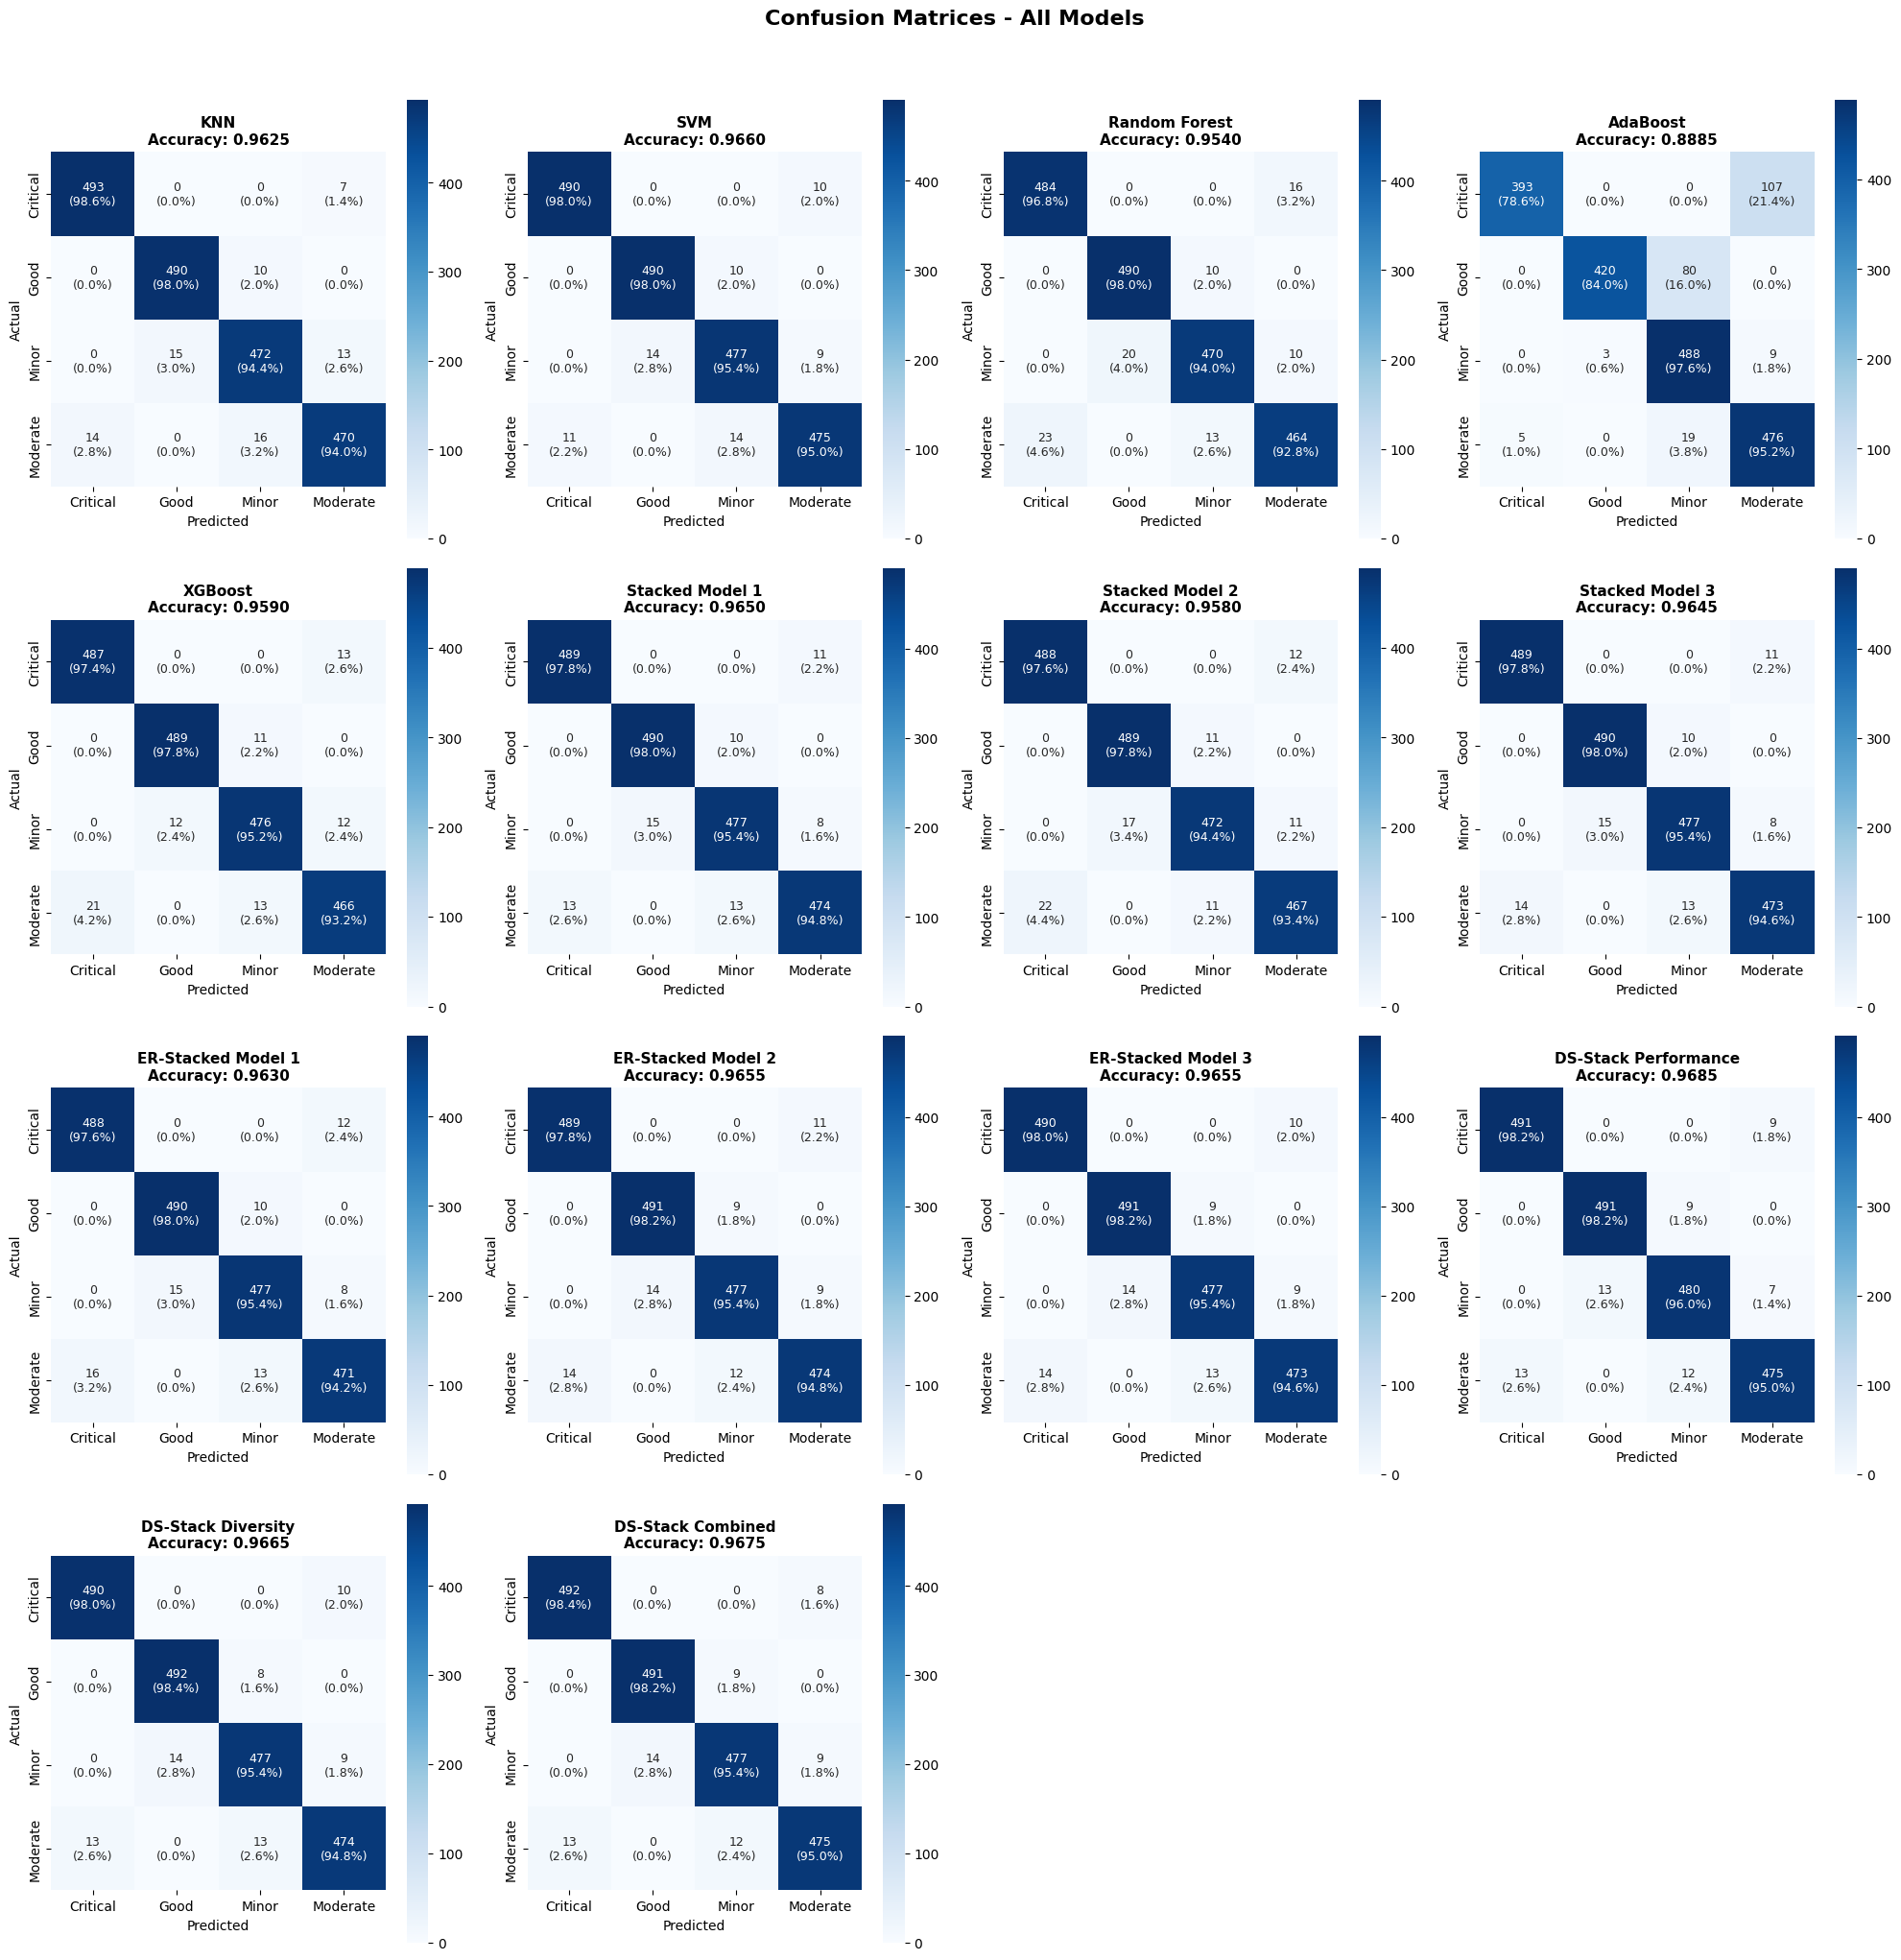


[OK] Confusion matrix heatmaps generated successfully


In [13]:
# Create performance visualizations
perf_visualizer = PerformanceVisualizer()

# Combine all models
all_models = {**base_models, **stacked_models, **er_stacked_models}
for name, model_info in ds_stacked_models.items():
    all_models[name] = model_info['model']

class_names = label_encoder.classes_.tolist()

# Generate comparison charts
perf_visualizer.plot_model_comparison(comparison_df)

# Generate ROC curves
perf_visualizer.plot_roc_curves(all_models, X_test, y_test, class_names)

# Generate confusion matrices
perf_visualizer.plot_confusion_matrices(all_models, X_test, y_test, class_names)

## 13. Target Metrics Verification

In [14]:
# Verify Stacked Model 1 meets target metrics
verification = evaluator.verify_targets('Stacked Model 1', tolerance=0.05)

print("\n" + "="*60)
print("TARGET METRICS VERIFICATION - Stacked Model 1")
print("="*60)
print(f"\n{'Metric':<12} {'Target':>10} {'Actual':>10} {'Deviation':>12} {'Status':>10}")
print("-" * 60)

all_passed = True
for metric, result in verification.items():
    status = "[OK] PASSED" if result['passed'] else "[X] FAILED"
    if not result['passed']:
        all_passed = False
    print(f"{metric:<12} {result['target']:>10.4f} {result['actual']:>10.4f} {result['deviation']:>+11.2f}% {status:>10}")

print("-" * 60)
if all_passed:
    print("\n[OK] Stacked Model 1 MEETS all target performance metrics!")
else:
    print("\n[!] Some target metrics not met (within 5% tolerance)")


TARGET METRICS VERIFICATION - Stacked Model 1

Metric           Target     Actual    Deviation     Status
------------------------------------------------------------
AUC              0.9702     0.9981       +2.87% [OK] PASSED
RMSE             0.3355     0.3619       +7.88% [X] FAILED
Accuracy         0.9470     0.9650       +1.90% [OK] PASSED
Precision        0.9486     0.9650       +1.73% [OK] PASSED
------------------------------------------------------------

[!] Some target metrics not met (within 5% tolerance)


## 14. Explainable AI (SHAP + LIME)


[...] Initializing SHAP explainer...
   [OK] SHAP KernelExplainer initialized
   Background samples: 100

[...] Computing SHAP values for 50 samples...
   This may take a few minutes...


  0%|          | 0/50 [00:00<?, ?it/s]

   SHAP values shape: (50, 9, 4)
   X_sample shape: (50, 9)
   [OK] SHAP values computed successfully!

SHAP SUMMARY PLOT
   SHAP values shape: (50, 9, 4)
   X_sample shape: (50, 9)


<Figure size 1200x800 with 0 Axes>

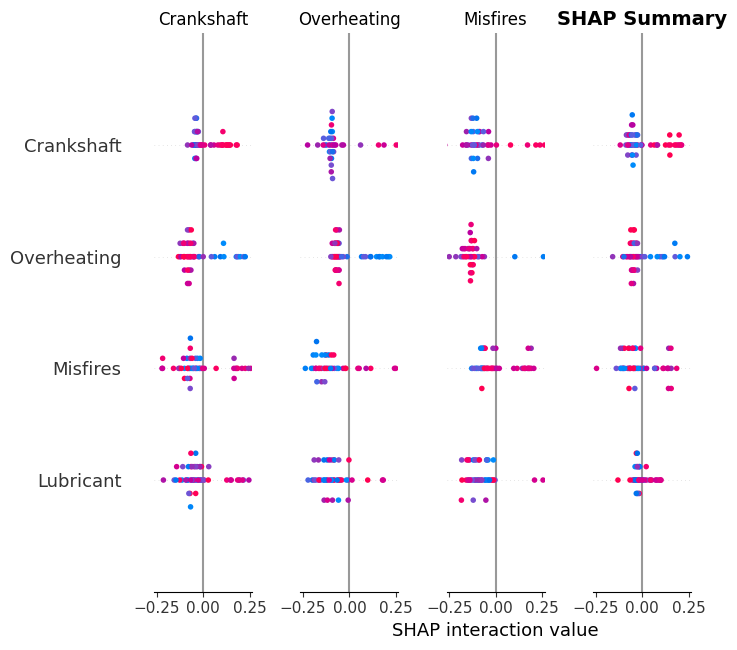


[OK] SHAP summary plot generated successfully

SHAP BAR PLOT


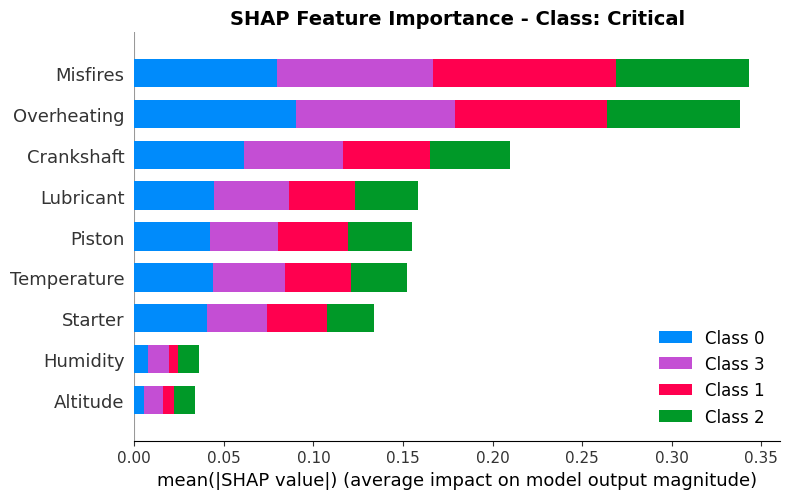


[OK] SHAP bar plot generated successfully


In [15]:
# Select best model for XAI
best_model = stacked_models['Stacked Model 1']

# Initialize XAI explainer
xai_explainer = XAIExplainer(best_model, feature_names, class_names)

# Initialize SHAP
xai_explainer.initialize_shap(X_train, max_samples=100)

# Compute SHAP values for a sample
X_sample = X_test[:50]
shap_values = xai_explainer.compute_shap_values(X_sample, nsamples=100)

# Plot SHAP summary
xai_explainer.plot_shap_summary(class_idx=0)
xai_explainer.plot_shap_bar(class_idx=0)


[...] Initializing LIME explainer...
   [OK] LIME TabularExplainer initialized
   Mode: classification
   Features: 9
   Classes: ['Critical', 'Good', 'Minor', 'Moderate']

[...] Generating LIME explanation...
   [OK] LIME explanation generated successfully

LIME EXPLANATION - Class: Critical

Predicted probabilities:
   Critical: 0.9927
   Good: 0.0003
   Minor: 0.0001
   Moderate: 0.0069

Feature contributions for Critical:
--------------------------------------------------
   Overheating > 0.82             : +0.0914
   Lubricant <= -0.75             : +0.0533
   Crankshaft > 0.78              : +0.0520
   Temperature > 0.76             : +0.0484
   -0.00 < Humidity <= 0.69       : -0.0087
   0.01 < Piston <= 0.76          : +0.0061
   Altitude <= -0.85              : +0.0036
   -0.78 < Starter <= -0.01       : +0.0025
   -0.01 < Misfires <= 0.83       : +0.0014
--------------------------------------------------

LIME EXPLANATION PLOT


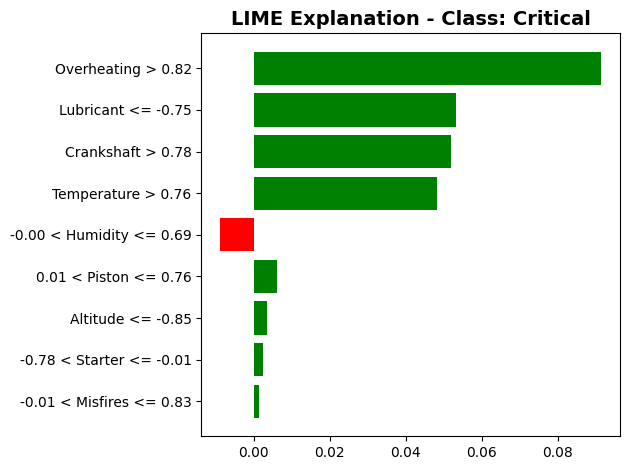


[OK] LIME explanation plot generated successfully


In [16]:
# LIME explanations
xai_explainer.initialize_lime(X_train)

# Explain a single instance
sample_instance = X_test[0]
lime_explanation = xai_explainer.explain_instance_lime(sample_instance)

# Display LIME explanation
xai_explainer.display_lime_text(lime_explanation)
xai_explainer.plot_lime_explanation(lime_explanation)

## 15. Deep Learning Classifiers Setup

This section introduces deep learning classifiers (CNN, LSTM, and hybrid models) for improved predictive maintenance accuracy.

In [26]:
# Install TensorFlow if not already installed
!pip install tensorflow --quiet

# Import deep learning classifiers
from vehms import (
    CNNClassifier, LSTMClassifier, CNNLSTMClassifier,
    GRUClassifier, AttentionLSTMClassifier,
    DeepStackedEnsemble, DynamicDeepStackedEnsemble
)

print("="*60)
print("DEEP LEARNING CLASSIFIERS LOADED")
print("="*60)
print("\nAvailable classifiers:")
print("  - CNNClassifier: 1D-CNN for tabular data")
print("  - LSTMClassifier: LSTM for sequential patterns")
print("  - CNNLSTMClassifier: Hybrid CNN-LSTM")
print("  - GRUClassifier: GRU (faster alternative to LSTM)")
print("  - AttentionLSTMClassifier: LSTM with attention mechanism")
print("\nAvailable ensembles:")
print("  - DeepStackedEnsemble: Stacking with DL meta-learner")
print("  - DynamicDeepStackedEnsemble: Auto-selection + DL stacking")


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
DEEP LEARNING CLASSIFIERS LOADED

Available classifiers:
  - CNNClassifier: 1D-CNN for tabular data
  - LSTMClassifier: LSTM for sequential patterns
  - CNNLSTMClassifier: Hybrid CNN-LSTM
  - GRUClassifier: GRU (faster alternative to LSTM)
  - AttentionLSTMClassifier: LSTM with attention mechanism

Available ensembles:
  - DeepStackedEnsemble: Stacking with DL meta-learner
  - DynamicDeepStackedEnsemble: Auto-selection + DL stacking


## 16. Individual Deep Learning Classifiers

Training and evaluating individual deep learning models:
- **CNN**: Convolutional Neural Network for local pattern extraction
- **LSTM**: Long Short-Term Memory for sequential dependencies
- **BiLSTM**: Bidirectional LSTM for enhanced context
- **CNN-LSTM**: Hybrid combining CNN feature extraction with LSTM modeling
- **GRU**: Gated Recurrent Unit (faster than LSTM)
- **Attention-LSTM**: LSTM with attention for interpretability

In [18]:
# Train individual deep learning classifiers
print("\n" + "="*60)
print("TRAINING DEEP LEARNING CLASSIFIERS")
print("="*60)

dl_models = {}

# 1. CNN Classifier
print("\n[1/6] Training CNN Classifier...")
cnn = CNNClassifier(
    filters=[64, 128, 256],
    dropout_rate=0.3,
    epochs=50,
    batch_size=32,
    verbose=0
)
cnn.fit(X_train, y_train)
dl_models['CNN'] = cnn
print(f"   CNN Training Accuracy: {cnn.score(X_train, y_train):.4f}")

# 2. LSTM Classifier
print("\n[2/6] Training LSTM Classifier...")
lstm = LSTMClassifier(
    lstm_units=[64, 32],
    dropout_rate=0.3,
    epochs=50,
    batch_size=32,
    verbose=0
)
lstm.fit(X_train, y_train)
dl_models['LSTM'] = lstm
print(f"   LSTM Training Accuracy: {lstm.score(X_train, y_train):.4f}")

# 3. Bidirectional LSTM
print("\n[3/6] Training Bidirectional LSTM...")
bilstm = LSTMClassifier(
    lstm_units=[64, 32],
    bidirectional=True,
    dropout_rate=0.3,
    epochs=50,
    batch_size=32,
    verbose=0
)
bilstm.fit(X_train, y_train)
dl_models['BiLSTM'] = bilstm
print(f"   BiLSTM Training Accuracy: {bilstm.score(X_train, y_train):.4f}")

# 4. CNN-LSTM Hybrid
print("\n[4/6] Training CNN-LSTM Hybrid...")
cnn_lstm = CNNLSTMClassifier(
    cnn_filters=[64, 128],
    lstm_units=[64],
    dropout_rate=0.3,
    epochs=50,
    batch_size=32,
    verbose=0
)
cnn_lstm.fit(X_train, y_train)
dl_models['CNN-LSTM'] = cnn_lstm
print(f"   CNN-LSTM Training Accuracy: {cnn_lstm.score(X_train, y_train):.4f}")

# 5. GRU Classifier
print("\n[5/6] Training GRU Classifier...")
gru = GRUClassifier(
    gru_units=[64, 32],
    dropout_rate=0.3,
    epochs=50,
    batch_size=32,
    verbose=0
)
gru.fit(X_train, y_train)
dl_models['GRU'] = gru
print(f"   GRU Training Accuracy: {gru.score(X_train, y_train):.4f}")

# 6. Attention LSTM
print("\n[6/6] Training Attention LSTM...")
att_lstm = AttentionLSTMClassifier(
    lstm_units=[64, 64],
    attention_units=64,
    dropout_rate=0.3,
    epochs=50,
    batch_size=32,
    verbose=0
)
att_lstm.fit(X_train, y_train)
dl_models['Attention-LSTM'] = att_lstm
print(f"   Attention-LSTM Training Accuracy: {att_lstm.score(X_train, y_train):.4f}")

print("\n" + "="*60)
print("[OK] All deep learning classifiers trained!")
print("="*60)


TRAINING DEEP LEARNING CLASSIFIERS

[1/6] Training CNN Classifier...


2026-04-25 02:40:56.197728: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M5 Max
2026-04-25 02:40:56.197772: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 64.00 GB
2026-04-25 02:40:56.197780: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 25.92 GB
2026-04-25 02:40:56.197815: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-25 02:40:56.197827: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-04-25 02:40:57.414146: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


   CNN Training Accuracy: 0.9685

[2/6] Training LSTM Classifier...
   LSTM Training Accuracy: 0.7829

[3/6] Training Bidirectional LSTM...
   BiLSTM Training Accuracy: 0.7799

[4/6] Training CNN-LSTM Hybrid...
   CNN-LSTM Training Accuracy: 0.9671

[5/6] Training GRU Classifier...
   GRU Training Accuracy: 0.6921

[6/6] Training Attention LSTM...
   Attention-LSTM Training Accuracy: 0.7770

[OK] All deep learning classifiers trained!


## 17. Deep Learning Classifiers Evaluation

In [19]:
# Evaluate deep learning classifiers
print("\n" + "="*60)
print("EVALUATING DEEP LEARNING CLASSIFIERS")
print("="*60)

dl_evaluator = ModelEvaluator()

for name, model in dl_models.items():
    print(f"\n[...] Evaluating {name}...")
    metrics = dl_evaluator.evaluate_model(model, X_test, y_test, name)
    print(f"   Accuracy: {metrics['Accuracy']:.4f}")
    print(f"   Precision: {metrics['Precision']:.4f}")
    print(f"   AUC: {metrics['AUC']:.4f}")
    print(f"   RMSE: {metrics['RMSE']:.4f}")

# Display comparison
print("\n" + "="*60)
print("DEEP LEARNING MODELS COMPARISON")
print("="*60)
dl_comparison = dl_evaluator.compare_models()
print(dl_comparison.to_string(index=False))


EVALUATING DEEP LEARNING CLASSIFIERS

[...] Evaluating CNN...
   Accuracy: 0.9620
   Precision: 0.9624
   AUC: 0.9975
   RMSE: 0.3924

[...] Evaluating LSTM...
   Accuracy: 0.7905
   Precision: 0.8393
   AUC: 0.9574
   RMSE: 1.0129

[...] Evaluating BiLSTM...
   Accuracy: 0.7690
   Precision: 0.8379
   AUC: 0.9801
   RMSE: 1.0766

[...] Evaluating CNN-LSTM...
   Accuracy: 0.9605
   Precision: 0.9608
   AUC: 0.9976
   RMSE: 0.3788

[...] Evaluating GRU...
   Accuracy: 0.7000
   Precision: 0.8036
   AUC: 0.9572
   RMSE: 1.2296

[...] Evaluating Attention-LSTM...
   Accuracy: 0.7695
   Precision: 0.8297
   AUC: 0.9673
   RMSE: 0.9445

DEEP LEARNING MODELS COMPARISON
         Model     RMSE     RMSD    MAE  Accuracy  Precision      AUC
      CNN-LSTM 0.378814 0.378814 0.0655    0.9605   0.960849 0.997634
           CNN 0.392428 0.392428 0.0670    0.9620   0.962426 0.997549
        BiLSTM 1.076569 1.076569 0.4630    0.7690   0.837884 0.980056
Attention-LSTM 0.944458 0.944458 0.3960    0.76

## 18. Deep Stacked Ensemble

Creating a stacked ensemble that uses traditional ML classifiers as base models and a deep learning model (CNN-LSTM) as the meta-learner.

In [20]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Define base classifiers for deep stacking
deep_base_classifiers = [
    ('RF', RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED)),
    ('XGB', XGBClassifier(n_estimators=100, random_state=RANDOM_SEED, eval_metric='mlogloss')),
    ('KNN', KNeighborsClassifier(n_neighbors=5)),
    ('SVM', SVC(kernel='rbf', probability=True, random_state=RANDOM_SEED)),
    ('AdaBoost', AdaBoostClassifier(n_estimators=100, random_state=RANDOM_SEED)),
]

# Create Deep Stacked Ensemble with CNN-LSTM meta-learner
deep_stack = DeepStackedEnsemble(
    base_classifiers=deep_base_classifiers,
    meta_learner_type='cnn_lstm',
    cv=5,
    use_probabilities=True,
    passthrough=False,
    verbose=1
)

deep_stack.fit(X_train, y_train)

# Display architecture
deep_stack.display_architecture()


DEEP STACKED ENSEMBLE TRAINING

Base Classifiers: 5
Meta-Learner: CNN_LSTM
CV Folds: 5
Use Probabilities: True
Passthrough: False

[...] Training base classifier: RF
   [OK] RF trained - Train Accuracy: 1.0000

[...] Training base classifier: XGB
   [OK] XGB trained - Train Accuracy: 1.0000

[...] Training base classifier: KNN
   [OK] KNN trained - Train Accuracy: 0.9722

[...] Training base classifier: SVM
   [OK] SVM trained - Train Accuracy: 0.9728

[...] Training base classifier: AdaBoost
   [OK] AdaBoost trained - Train Accuracy: 0.9019

[INFO] Meta-features shape: (8000, 20)

[...] Training CNN_LSTM meta-learner...
   [OK] Meta-learner trained - Train Accuracy: 0.9614

[OK] Deep Stacked Ensemble trained in 152.26 seconds

DEEP STACKED ENSEMBLE ARCHITECTURE

                    +----------------------------+
                    |    Input Features (9)     |
                    +----------------------------+
                                 |
                                 v

  

In [21]:
# Evaluate Deep Stacked Ensemble
deep_stack_metrics = dl_evaluator.evaluate_model(deep_stack, X_test, y_test, 'Deep-Stack-CNN-LSTM')

print("\n" + "="*60)
print("DEEP STACKED ENSEMBLE RESULTS")
print("="*60)
print(f"\nTest Accuracy: {deep_stack_metrics['Accuracy']:.4f}")
print(f"Test Precision: {deep_stack_metrics['Precision']:.4f}")
print(f"Test AUC: {deep_stack_metrics['AUC']:.4f}")
print(f"Test RMSE: {deep_stack_metrics['RMSE']:.4f}")

# Compare base classifier accuracies
print("\n[INFO] Base Classifier Accuracies:")
base_accs = deep_stack.get_base_accuracies(X_test, y_test)
for name, acc in base_accs.items():
    print(f"   {name}: {acc:.4f}")


DEEP STACKED ENSEMBLE RESULTS

Test Accuracy: 0.9625
Test Precision: 0.9630
Test AUC: 0.9970
Test RMSE: 0.3450

[INFO] Base Classifier Accuracies:
   RF: 0.9540
   XGB: 0.9590
   KNN: 0.9625
   SVM: 0.9660
   AdaBoost: 0.8885


## 19. Dynamic Deep Stacked Ensemble

Automatically selects optimal base classifiers using diversity and performance metrics, then uses a deep learning meta-learner.

In [22]:
# Create Dynamic Deep Stacked Ensemble
dynamic_deep_stack = DynamicDeepStackedEnsemble(
    selection_method='combined',  # Balance performance and diversity
    top_k=5,                      # Select top 5 classifiers
    performance_weight=0.6,       # 60% performance, 40% diversity
    meta_learner_type='cnn_lstm', # Use CNN-LSTM as meta-learner
    cv=5,
    verbose=1
)

dynamic_deep_stack.fit(X_train, y_train)

# Display selection summary
dynamic_deep_stack.display_selection_summary()

# Display architecture
dynamic_deep_stack.display_architecture()


DYNAMIC DEEP STACKED ENSEMBLE

Selection Method: combined
Top-K Classifiers: 5
[...] Fitting all classifiers...
   LR: 0.9750
   KNN: 0.9669
   LDA: 0.9731
   GNB: 0.9762
   SVM: 0.9775
   DT: 0.9100
   RF: 0.9694
   AdaBoost: 0.9000
   GB: 0.9719
   XGBoost: 0.9725

[CHART] Individual Classifier Performance (Ranked):
--------------------------------------------------
    1. SVM        0.9775 |************************************************
    2. GNB        0.9762 |************************************************
    3. LR         0.9750 |************************************************
    4. LDA        0.9731 |************************************************
    5. XGBoost    0.9725 |************************************************
    6. GB         0.9719 |************************************************
    7. RF         0.9694 |************************************************
    8. KNN        0.9669 |************************************************
    9. DT         0.9100 |**

In [23]:
# Evaluate Dynamic Deep Stacked Ensemble
dynamic_deep_metrics = dl_evaluator.evaluate_model(
    dynamic_deep_stack, X_test, y_test, 'Dynamic-Deep-Stack'
)

print("\n" + "="*60)
print("DYNAMIC DEEP STACKED ENSEMBLE RESULTS")
print("="*60)
print(f"\nTest Accuracy: {dynamic_deep_metrics['Accuracy']:.4f}")
print(f"Test Precision: {dynamic_deep_metrics['Precision']:.4f}")
print(f"Test AUC: {dynamic_deep_metrics['AUC']:.4f}")
print(f"Test RMSE: {dynamic_deep_metrics['RMSE']:.4f}")


DYNAMIC DEEP STACKED ENSEMBLE RESULTS

Test Accuracy: 0.9610
Test Precision: 0.9609
Test AUC: 0.9955
Test RMSE: 0.3674


## 20. Comprehensive Model Comparison

Comparing all models: Traditional ML, Deep Learning, and Hybrid Stacking approaches.

In [24]:
# Combine all results for comprehensive comparison
print("\n" + "="*70)
print("COMPREHENSIVE MODEL COMPARISON (ML + DL + Hybrid)")
print("="*70)

# Get all comparison results
all_comparison = dl_evaluator.compare_models()
print("\n" + all_comparison.to_string(index=False))

# Find best model
best_dl_model = all_comparison.loc[all_comparison['Accuracy'].idxmax()]
print(f"\n" + "="*70)
print(f"[BEST DEEP LEARNING MODEL] {best_dl_model['Model']}")
print(f"   Accuracy:  {best_dl_model['Accuracy']:.4f}")
print(f"   Precision: {best_dl_model['Precision']:.4f}")
print(f"   AUC:       {best_dl_model['AUC']:.4f}")
print(f"   RMSE:      {best_dl_model['RMSE']:.4f}")
print("="*70)


COMPREHENSIVE MODEL COMPARISON (ML + DL + Hybrid)

              Model     RMSE     RMSD    MAE  Accuracy  Precision      AUC
           CNN-LSTM 0.378814 0.378814 0.0655    0.9605   0.960849 0.997634
                CNN 0.392428 0.392428 0.0670    0.9620   0.962426 0.997549
Deep-Stack-CNN-LSTM 0.344964 0.344964 0.0580    0.9625   0.962995 0.997027
 Dynamic-Deep-Stack 0.367423 0.367423 0.0630    0.9610   0.960914 0.995492
             BiLSTM 1.076569 1.076569 0.4630    0.7690   0.837884 0.980056
     Attention-LSTM 0.944458 0.944458 0.3960    0.7695   0.829716 0.967331
               LSTM 1.012917 1.012917 0.4140    0.7905   0.839333 0.957360
                GRU 1.229634 1.229634 0.6030    0.7000   0.803616 0.957230

[BEST DEEP LEARNING MODEL] Deep-Stack-CNN-LSTM
   Accuracy:  0.9625
   Precision: 0.9630
   AUC:       0.9970
   RMSE:      0.3450


## 21. Final Summary

In [25]:
# Final summary
best_model_row = comparison_df.iloc[0]

print("="*80)
print("VEHMS PREDICTIVE MAINTENANCE - FINAL SUMMARY")
print("="*80)

print(f"\n[TROPHY] Best Model: {best_model_row['Model']}")
print(f"\nPerformance Metrics:")
print(f"   - AUC:       {best_model_row['AUC']:.4f}")
print(f"   - Accuracy:  {best_model_row['Accuracy']:.4f} ({best_model_row['Accuracy']*100:.2f}%)")
print(f"   - Precision: {best_model_row['Precision']:.4f}")
print(f"   - RMSE:      {best_model_row['RMSE']:.4f}")

print(f"\nModels Evaluated: {len(comparison_df)}")
print(f"   - Base Classifiers: {len(base_models)}")
print(f"   - Proposed Stacked: {len(stacked_models)}")
print(f"   - Existing Research: {len(er_stacked_models)}")
print(f"   - Dynamic Selection: {len(ds_stacked_models)}")

print("\n" + "="*80)
print("[OK] VEHMS ANALYSIS COMPLETE")
print("="*80)

VEHMS PREDICTIVE MAINTENANCE - FINAL SUMMARY

[TROPHY] Best Model: ER-Stacked Model 2

Performance Metrics:
   - AUC:       0.9984
   - Accuracy:  0.9655 (96.55%)
   - Precision: 0.9654
   - RMSE:      0.3667

Models Evaluated: 14
   - Base Classifiers: 5
   - Proposed Stacked: 3
   - Existing Research: 3
   - Dynamic Selection: 3

[OK] VEHMS ANALYSIS COMPLETE
